In [1]:
# core
import os
import numpy as np
import pandas as pd

# modeling
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, regularizers

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# metrics & plotting
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# feature importance (model-agnostic)
from sklearn.inspection import permutation_importance
from sklearn.metrics import make_scorer

# reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

# create visual folder
os.makedirs("./visual", exist_ok=True)


2025-11-18 13:54:11.236179: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-18 13:54:11.302634: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-18 13:54:12.646680: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
# path to your training data
data_path = "./data/train_mp.csv"  # change if needed
df = pd.read_csv(data_path)

# exclude non-feature columns (same list as before)
non_feature_cols = {
    "material_id", "formula", "composition", "composition_obj",
    "formation_energy_per_atom", "band_gap"
}

# feature matrix (numeric only)
feature_cols = [c for c in df.columns if c not in non_feature_cols]
X_all = df[feature_cols].select_dtypes(include=[np.number]).copy()

# label
target_col = "formation_energy_per_atom"
y_all = df[target_col].astype(float).copy()

print("n_samples:", len(df))
print("n_features (numeric):", X_all.shape[1])
print("first 5 feature columns:", feature_cols[:5])
X_all.head()


n_samples: 6419
n_features (numeric): 250
first 5 feature columns: ['H', 'He', 'Li', 'Be', 'B']


,H,He,Li,Be,B,C,N,O,F,Ne,...,MagpieData range GSmagmom,MagpieData mean GSmagmom,MagpieData avg_dev GSmagmom,MagpieData mode GSmagmom,MagpieData minimum SpaceGroupNumber,MagpieData maximum SpaceGroupNumber,MagpieData range SpaceGroupNumber,MagpieData mean SpaceGroupNumber,MagpieData avg_dev SpaceGroupNumber,MagpieData mode SpaceGroupNumber
0,0.0,0,0.0,0,0.0,0.750000,0.0,0.0,0.0,0,...,0.000000,0.00000,0.000000,0.000000,194.0,229.0,35.0,202.750000,13.125000,194.0
1,0.0,0,0.0,0,0.0,0.200000,0.0,0.0,0.0,0,...,2.110663,1.68853,0.675412,2.110663,194.0,229.0,35.0,222.000000,11.200000,229.0
2,0.0,0,0.0,0,0.0,0.558824,0.0,0.0,0.0,0,...,0.000000,0.00000,0.000000,0.000000,194.0,194.0,0.0,194.000000,0.000000,194.0
3,0.0,0,0.0,0,0.0,0.600000,0.0,0.0,0.0,0,...,0.000000,0.00000,0.000000,0.000000,194.0,194.0,0.0,194.000000,0.000000,194.0
4,0.0,0,0.0,0,0.0,0.555556,0.0,0.0,0.0,0,...,0.000000,0.00000,0.000000,0.000000,194.0,225.0,31.0,207.777778,15.308642,194.0


In [3]:
# split
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=RANDOM_STATE
)

# simple imputation (median)
X_train = X_train.fillna(X_train.median(numeric_only=True))
X_test  = X_test.fillna(X_train.median(numeric_only=True))  # use train medians

# standardize features (fit on train only)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print("train shape:", X_train_s.shape, "| test shape:", X_test_s.shape)


train shape: (5135, 250) | test shape: (1284, 250)


In [4]:
# straightforward MLP — adjust depth/width if needed
def build_mlp(n_in: int) -> keras.Model:
    model = keras.Sequential([
        layers.Input(shape=(n_in,)),
        layers.Dense(256, activation="relu", kernel_regularizer=regularizers.l2(1e-5)),
        layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(1e-5)),
        layers.Dense(64,  activation="relu", kernel_regularizer=regularizers.l2(1e-5)),
        layers.Dense(1,   activation="linear")
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="mse",
        metrics=[keras.metrics.MeanAbsoluteError(name="mae")]
    )
    return model

mlp = build_mlp(X_train_s.shape[1])
mlp.summary()


2025-11-18 13:54:34.118587: I tensorflow/core/common_runtime/gpu/gpu_device.cc:2322] Ignoring visible gpu device (device: 4, name: NVIDIA T400 4GB, pci bus id: 0000:e3:00.0, compute capability: 7.5) with core count: 6. The minimum required count is 8. You can adjust this requirement with the env var TF_MIN_GPU_MULTIPROCESSOR_COUNT.
2025-11-18 13:54:34.550949: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1928] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22480 MB memory:  -> device: 0, name: NVIDIA RTX A5000, pci bus id: 0000:31:00.0, compute capability: 8.6
2025-11-18 13:54:34.552295: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1928] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 22480 MB memory:  -> device: 1, name: NVIDIA RTX A5000, pci bus id: 0000:4b:00.0, compute capability: 8.6
2025-11-18 13:54:34.553410: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1928] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 2248

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        64,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 105,473 (412.00 KB)

 Trainable params: 105,473 (412.00 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
EPOCHS = 300
BATCH_SIZE = 256
PATIENCE = 20

es  = callbacks.EarlyStopping(
    monitor="val_loss", patience=PATIENCE, restore_best_weights=True
)
rlr = callbacks.ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=max(5, PATIENCE//3),
    min_lr=1e-6
)

history = mlp.fit(
    X_train_s, y_train,
    validation_split=0.2,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1,
    callbacks=[es, rlr]
)


Epoch 1/300


I0000 00:00:1763441682.260898 1362018 service.cc:145] XLA service 0x7f050c004380 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1763441682.260985 1362018 service.cc:153]   StreamExecutor device (0): NVIDIA RTX A5000, Compute Capability 8.6
I0000 00:00:1763441682.260995 1362018 service.cc:153]   StreamExecutor device (1): NVIDIA RTX A5000, Compute Capability 8.6
I0000 00:00:1763441682.261002 1362018 service.cc:153]   StreamExecutor device (2): NVIDIA RTX A5000, Compute Capability 8.6
I0000 00:00:1763441682.261007 1362018 service.cc:153]   StreamExecutor device (3): NVIDIA RTX A5000, Compute Capability 8.6
2025-11-18 13:54:42.302439: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-11-18 13:54:42.480936: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:465] Loaded cuDNN version 8907
I0000 00:00:1763441684.363596 136

 1/17 ━━━━━━━━━━━━━━━━━━━━ 1:19 5s/step - loss: 1.1724 - mae: 0.8999

I0000 00:00:1763441686.166961 1362018 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
I0000 00:00:1763441686.749202 1362294 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_225', 8 bytes spill stores, 8 bytes spill loads



17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 251ms/step - loss: 0.4570 - mae: 0.4784 - val_loss: 0.2671 - val_mae: 0.3202 - learning_rate: 0.0010
Epoch 2/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.2056 - mae: 0.2905 - val_loss: 0.2049 - val_mae: 0.2741 - learning_rate: 0.0010
Epoch 3/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1726 - mae: 0.2487 - val_loss: 0.1927 - val_mae: 0.2476 - learning_rate: 0.0010
Epoch 4/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1529 - mae: 0.2216 - val_loss: 0.1855 - val_mae: 0.2479 - learning_rate: 0.0010
Epoch 5/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1408 - mae: 0.2061 - val_loss: 0.1804 - val_mae: 0.2428 - learning_rate: 0.0010
Epoch 6/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1327 - mae: 0.1960 - val_loss: 0.1783 - val_mae: 0.2399 - learning_rate: 0.0010
Epoch 7/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1270 - mae: 0.1882 - val_loss: 0.1760 - val_mae: 0.2388 - learning_rate: 0.0010
Epoch 8/300
17/17

In [6]:
# (optional) save the trained model
os.makedirs("./model_mlp", exist_ok=True)
mlp.save("./model_mlp/ann_mlp.keras")
np.savez("./model_mlp/scaler_mean_std.npz",
         mean=scaler.mean_, scale=scaler.scale_, var=scaler.var_)


In [7]:
def eval_regression(y_true, y_pred, label=""):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f"{label} RMSE: {rmse:.3f} | MAE: {mae:.3f} | R2: {r2:.3f}")
    return rmse, mae, r2

# predictions
yhat_tr = mlp.predict(X_train_s, verbose=0).ravel()
yhat_te = mlp.predict(X_test_s,  verbose=0).ravel()

print("== training ==")
tr_metrics = eval_regression(y_train, yhat_tr, "train")

print("\n== test ==")
te_metrics = eval_regression(y_test, yhat_te, "test")


I0000 00:00:1763441715.364939 1373024 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_18', 8 bytes spill stores, 8 bytes spill loads



== training ==
train RMSE: 0.312 | MAE: 0.143 | R2: 0.877

== test ==
test RMSE: 0.472 | MAE: 0.253 | R2: 0.746


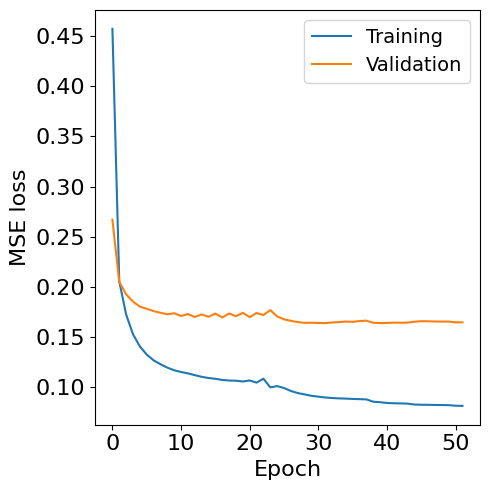

In [8]:
plt.figure(figsize=(5,5))
plt.plot(history.history["loss"],     label="Training")
plt.plot(history.history["val_loss"], label="Validation")
plt.xlabel("Epoch", fontsize=16)
plt.ylabel("MSE loss", fontsize=16)
plt.xticks(fontsize=16); plt.yticks(fontsize=16)
plt.legend(fontsize=14)
plt.tight_layout()
plt.savefig('./visual/fig_s1c.jpg', format='jpg', dpi=500, bbox_inches='tight')
plt.show()


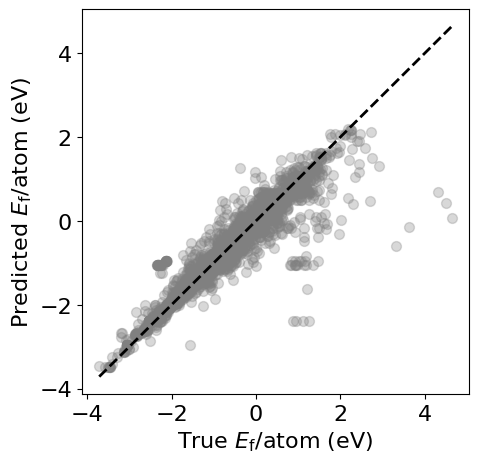

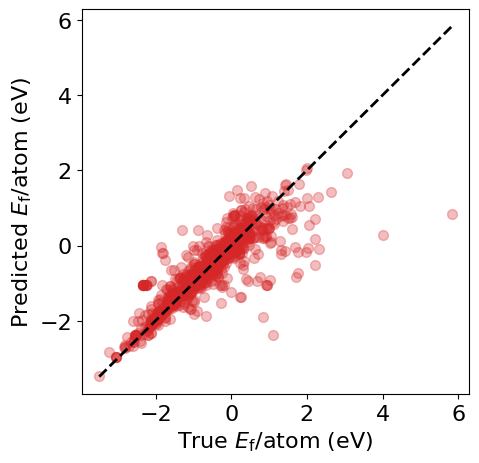

In [11]:
# --- Train parity ---
plt.figure(figsize=(5,5))
plt.scatter(y_train, yhat_tr, s=50, alpha=0.3, c="grey")
lims = [min(y_train.min(), yhat_tr.min()), max(y_train.max(), yhat_tr.max())]
plt.plot(lims, lims, linewidth=2, color="black", linestyle="--")
plt.xlabel(r"True $E_\mathrm{f}$/atom (eV)", fontsize=16)
plt.ylabel(r"Predicted $E_\mathrm{f}$/atom (eV)", fontsize=16)
plt.xticks(fontsize=16); plt.yticks(fontsize=16)
plt.savefig('./visual/fig_s1d.jpg', format='jpg', dpi=500, bbox_inches='tight')
plt.show()

# --- Test parity ---
plt.figure(figsize=(5,5))
plt.scatter(y_test, yhat_te, s=50, alpha=0.3, c="tab:red")
lims = [min(y_test.min(), yhat_te.min()), max(y_test.max(), yhat_te.max())]
plt.plot(lims, lims, linewidth=2, color="black", linestyle="--")
plt.xlabel(r"True $E_\mathrm{f}$/atom (eV)", fontsize=16)
plt.ylabel(r"Predicted $E_\mathrm{f}$/atom (eV)", fontsize=16)
plt.xticks(fontsize=16); plt.yticks(fontsize=16)
plt.savefig('./visual/fig2b.jpg', format='jpg', dpi=500, bbox_inches='tight')
plt.show()


In [ ]:
# # === SAFE PERMUTATION IMPORTANCE FOR KERAS MODELS ===
# # Avoid joblib multiprocessing (n_jobs=1) so TF/Keras isn't reloaded in workers (no GPU OOM).
# # Optionally subsample for speed.

# from sklearn.inspection import permutation_importance
# from sklearn.metrics import make_scorer, mean_squared_error
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns

# # (Optional) subsample test set for speed
# MAX_SAMPLES = 3000  # adjust or set to None to use all
# if (MAX_SAMPLES is not None) and (X_test_s.shape[0] > MAX_SAMPLES):
#     rng = np.random.default_rng(42)
#     idx = rng.choice(X_test_s.shape[0], size=MAX_SAMPLES, replace=False)
#     X_pi = X_test_s[idx]
#     y_pi = np.asarray(y_test)[idx]
# else:
#     X_pi = X_test_s
#     y_pi = np.asarray(y_test)

# # scorer: negative MSE (higher is better)
# neg_mse_scorer = make_scorer(mean_squared_error, greater_is_better=False)

# # IMPORTANT: n_jobs=1 (no subprocesses); n_repeats can be reduced if slow
# perm = permutation_importance(
#     mlp,
#     X_pi,
#     y_pi,
#     scoring=neg_mse_scorer,
#     n_repeats=8,          # adjust for more stability
#     random_state=RANDOM_STATE,
#     n_jobs=1              # <-- key change: single-process to avoid pickling/GPU init
# )

# # collect and plot top-10
# importances = pd.Series(perm.importances_mean, index=X_train.columns)
# imp_top = importances.sort_values(ascending=False).head(10)

# # map original feature names → Feature #XXX (your style)
# feature_map = {
#     feat: f"#{str(X_train.columns.get_loc(feat)+1).zfill(3)}"
#     for feat in imp_top.index
# }
# imp_top_short = imp_top.rename(index=feature_map)




In [ ]:
# import matplotlib.ticker as mticker

# plt.figure(figsize=(5,5))
# sns.barplot(x=imp_top_short.values, y=imp_top_short.index, palette="viridis")
# plt.xlabel("Permutation importance", fontsize=16)
# plt.ylabel("Feature", fontsize=16)

# max_val = float(max(1e-12, imp_top_short.max()))
# tick_step = max_val/5
# ticks = np.arange(0, max_val + tick_step, tick_step)
# plt.xticks(ticks, fontsize=16)
# plt.yticks(fontsize=16)

# # Control digits after decimal
# plt.gca().xaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))

# plt.savefig('./visual/fig2l.jpg', format='jpg', dpi=500, bbox_inches='tight')
# plt.show()


# lookup = pd.DataFrame.from_dict(feature_map, orient="index", columns=["Short name"])
# display(lookup)